In [ ]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


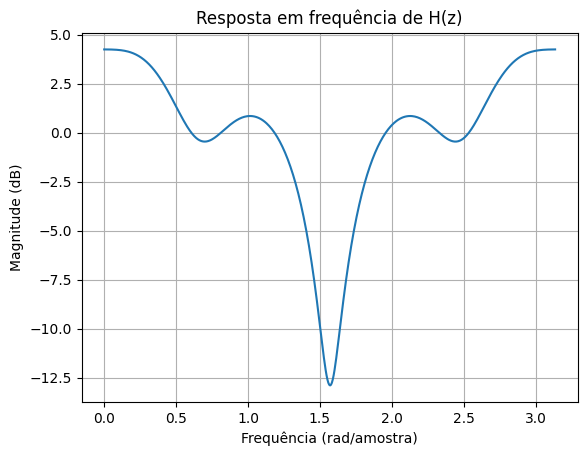

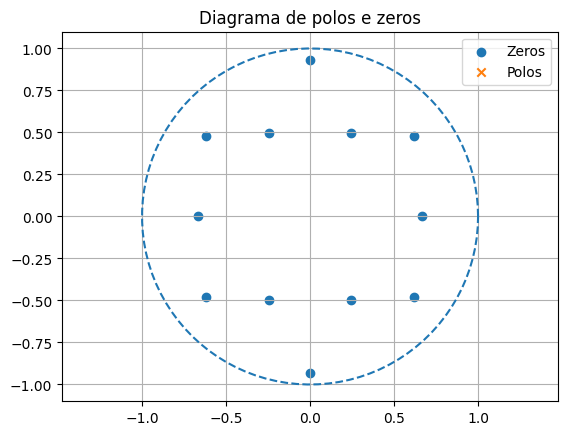

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, lfilter
from scipy.signal import tf2zpk
from IPython.display import Audio
import scipy.io.wavfile as wav
from google.colab import files

# Coeficientes do numerador (b)
# posições correspondem aos atrasos
b = np.zeros(13)

b[0] = 1
b[2] = 0.49
b[6] = 0.2401
b[8] = -0.0576
b[10] = -0.0282
b[12] = -0.0138

# Denominador (a) = 1 (FIR)
a = [1]

# Resposta em frequência

w, H = freqz(b, a)

plt.figure()
plt.plot(w, 20*np.log10(np.abs(H)))
plt.title("Resposta em frequência de H(z)")
plt.xlabel("Frequência (rad/amostra)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

# Polos e zeros

zeros, polos, _ = tf2zpk(b, a)

plt.figure()
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label="Zeros")
plt.scatter(np.real(polos), np.imag(polos), marker='x', label="Polos")

# círculo unitário
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--')

plt.legend()
plt.title("Diagrama de polos e zeros")
plt.axis('equal')
plt.grid()
plt.show()

Saving handel.wav to handel (6).wav


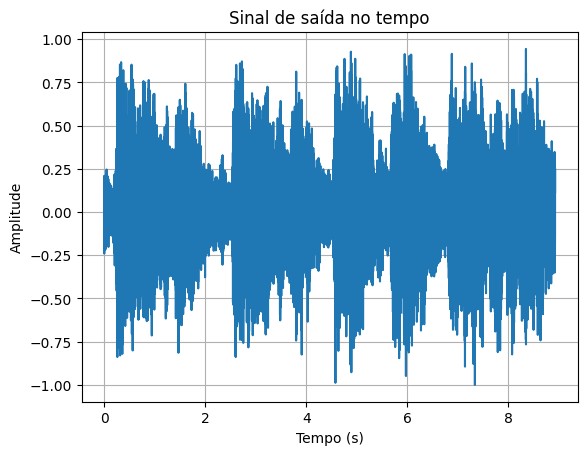

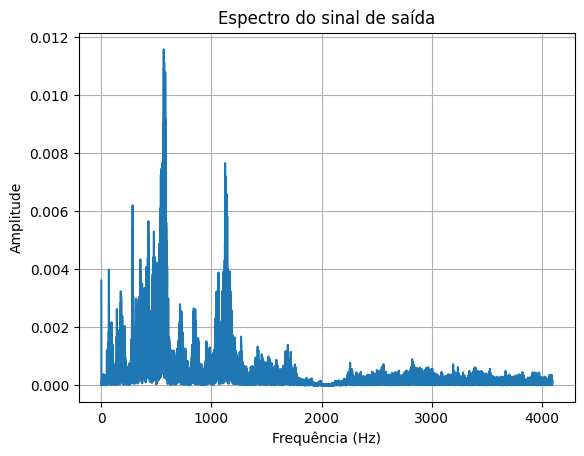

In [ ]:
# Upload do arquivo de áudio
uploaded = files.upload()

# Nome do arquivo enviado
nome = list(uploaded.keys())[0]

# Leitura do áudio
fs, x = wav.read(nome)

# Conversão para float (evita problemas numéricos)
x = x.astype(float)

# Normalização do sinal entre -1 e 1
x = x / np.max(np.abs(x))

# Aplicação do sistema H(z) ao sinal de entrada
y = lfilter(b, a, x)

# Normalização do sinal de saída
y = y / np.max(np.abs(y))

# Vetor de tempo para plot
t = np.linspace(0, len(y)/fs, len(y))

# Plot do sinal de saída no tempo
plt.figure()
plt.plot(t, y)
plt.title("Sinal de saída no tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Cálculo do espectro do sinal de saída
f, Y = calculate_spectrum(y, fs)

# Plot do espectro
plt.figure()
plt.plot(f, Y)
plt.title("Espectro do sinal de saída")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


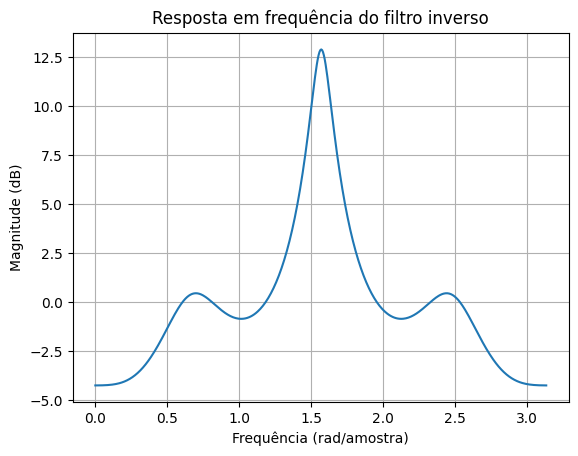

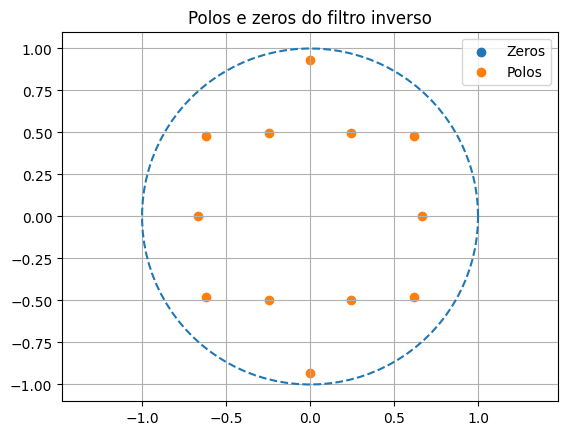

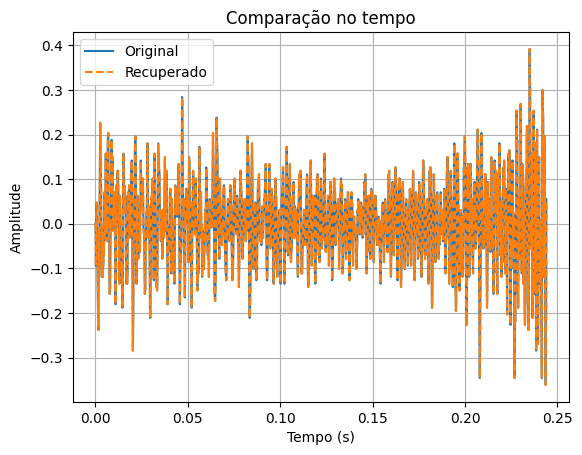

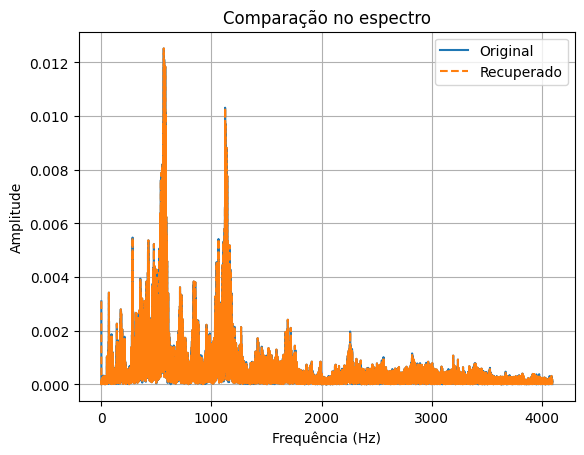

In [ ]:
# Projeto do filtro inverso
# H_inv(z) = 1 / H(z)
# Para FIR, isso implica trocar numerador e denominador

b_inv = a          # numerador do inverso
a_inv = b          # denominador do inverso

# Resposta em frequência do filtro inverso
w, H_inv = freqz(b_inv, a_inv)

plt.figure()
plt.plot(w, 20*np.log10(np.abs(H_inv)))
plt.title("Resposta em frequência do filtro inverso")
plt.xlabel("Frequência (rad/amostra)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

# Polos e zeros do filtro inverso
zeros_inv, polos_inv, _ = tf2zpk(b_inv, a_inv)

plt.figure()
plt.scatter(np.real(zeros_inv), np.imag(zeros_inv), label="Zeros")
plt.scatter(np.real(polos_inv), np.imag(polos_inv), label="Polos")

# Círculo unitário
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--')

plt.legend()
plt.title("Polos e zeros do filtro inverso")
plt.axis('equal')
plt.grid()
plt.show()

# Aplicação do filtro inverso ao sinal já filtrado
x_rec = lfilter(b_inv, a_inv, y)

# Normalização
x_rec = x_rec / np.max(np.abs(x_rec))

# Vetor de tempo
t = np.linspace(0, len(x)/fs, len(x))

# Comparação no tempo
plt.figure()
plt.plot(t[:2000], x[:2000], label="Original")
plt.plot(t[:2000], x_rec[:2000], '--', label="Recuperado")
plt.title("Comparação no tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

# Espectros
f1, X1 = calculate_spectrum(x, fs)
f2, X2 = calculate_spectrum(x_rec, fs)

plt.figure()
plt.plot(f1, X1, label="Original")
plt.plot(f2, X2, '--', label="Recuperado")
plt.title("Comparação no espectro")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()


/tmp/ipykernel_3299/412863545.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20*np.log10(np.abs(H)), label=f"a = {a_val}")


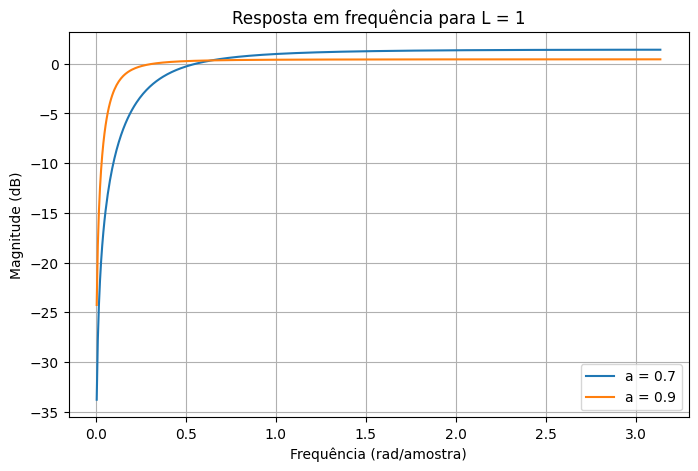

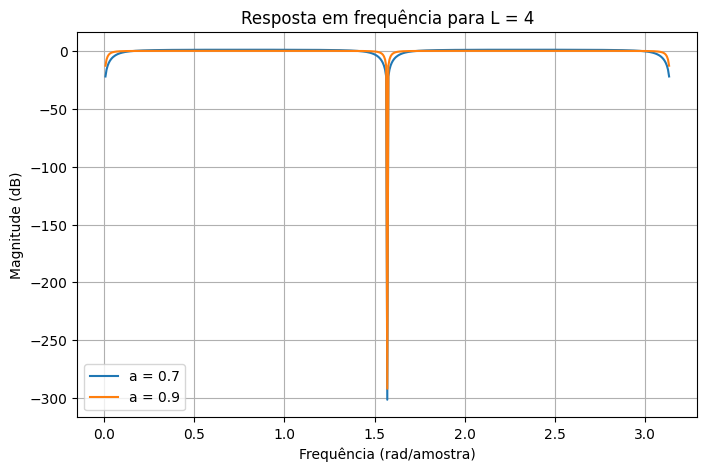

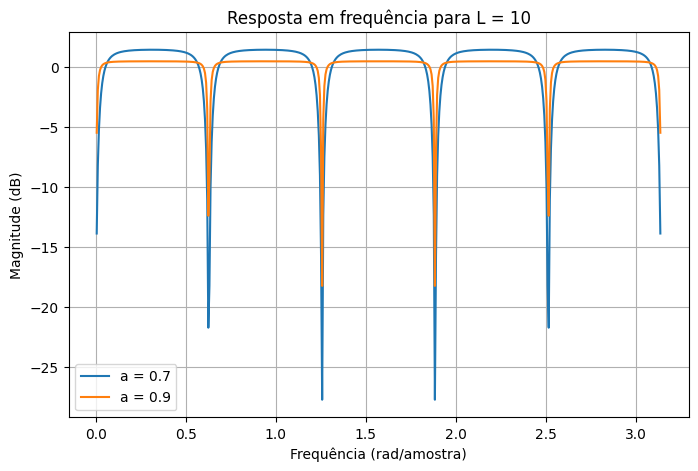

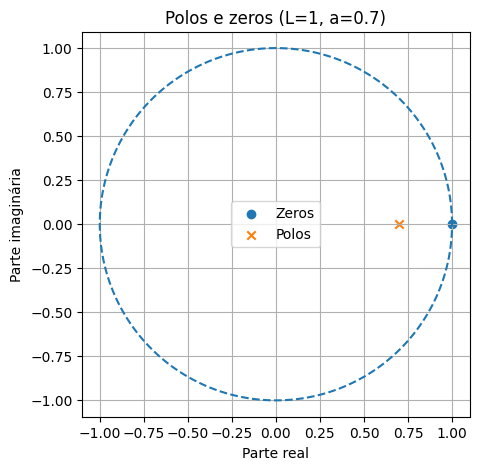

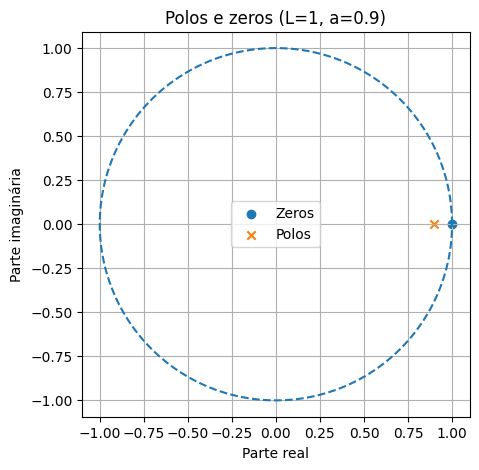

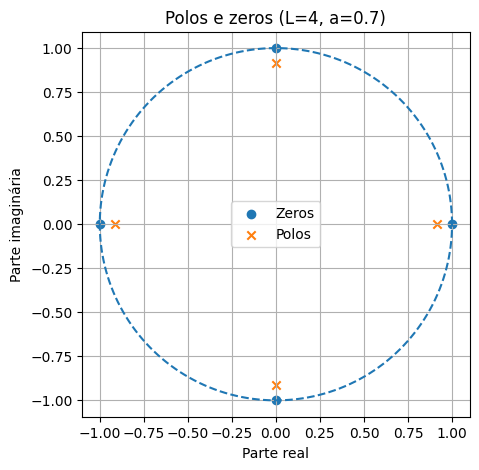

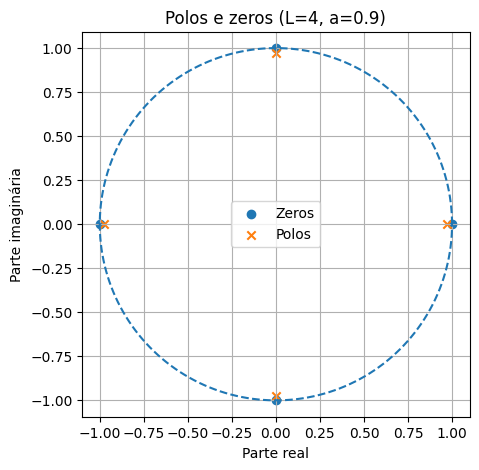

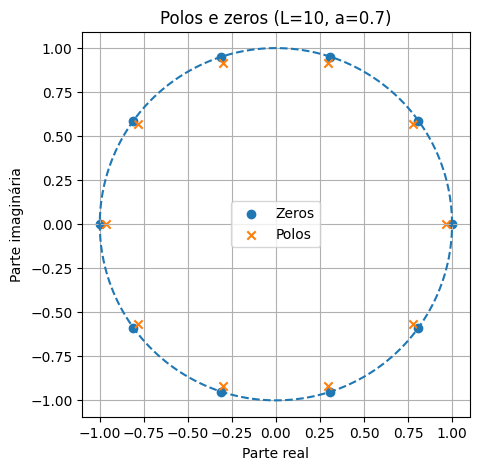

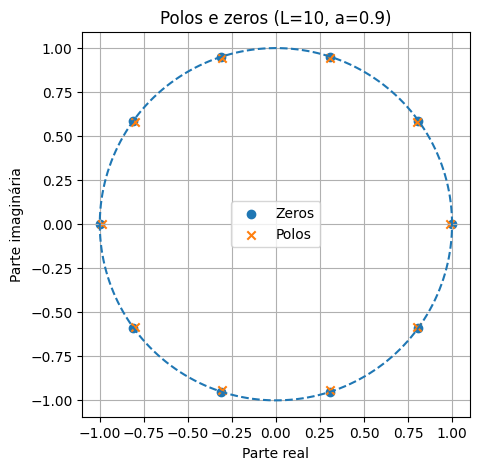

In [ ]:
valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

# RESPOSTA EM FREQUÊNCIA

for L in valores_L:

    plt.figure(figsize=(8,5))

    for a_val in valores_a:

        # Numerador: (1 - z^-L)
        b = np.zeros(L+1)
        b[0] = 1
        b[-1] = -1

        # Denominador: (1 - a*z^-L)
        a = np.zeros(L+1)
        a[0] = 1
        a[-1] = -a_val

        # Resposta em frequência
        w, H = freqz(b, a)

        plt.plot(w, 20*np.log10(np.abs(H)), label=f"a = {a_val}")

    plt.title(f"Resposta em frequência para L = {L}")
    plt.xlabel("Frequência (rad/amostra)")
    plt.ylabel("Magnitude (dB)")
    plt.legend()
    plt.grid()
    plt.show()

# DIAGRAMAS DE POLOS E ZEROS

for L in valores_L:
    for a_val in valores_a:

        # Numerador
        b = np.zeros(L+1)
        b[0] = 1
        b[-1] = -1

        # Denominador
        a = np.zeros(L+1)
        a[0] = 1
        a[-1] = -a_val

        # Cálculo de polos e zeros
        zeros, polos, _ = tf2zpk(b, a)

        plt.figure(figsize=(5,5))

        # Zeros
        plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label="Zeros")

        # Polos
        plt.scatter(np.real(polos), np.imag(polos), marker='x', label="Polos")

        # Círculo unitário
        theta = np.linspace(0, 2*np.pi, 200)
        plt.plot(np.cos(theta), np.sin(theta), linestyle='--')

        plt.title(f"Polos e zeros (L={L}, a={a_val})")
        plt.xlabel("Parte real")
        plt.ylabel("Parte imaginária")
        plt.legend()
        plt.grid()
        plt.axis('equal')

        plt.show()

Saving handel.wav to handel (10).wav


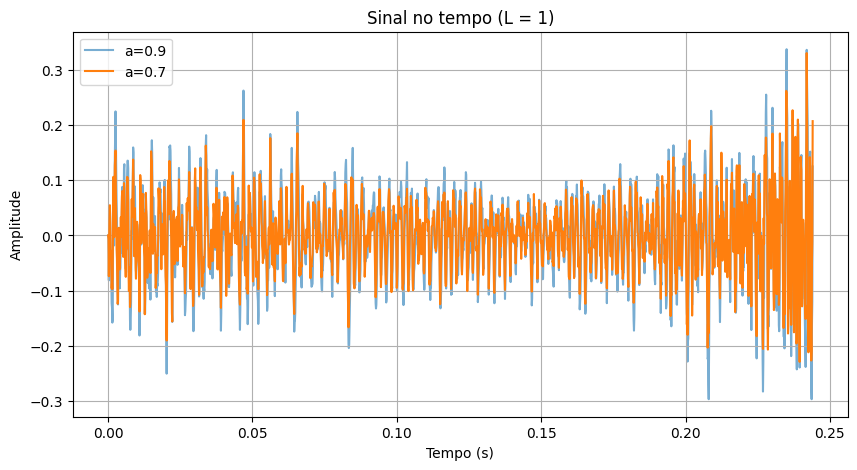

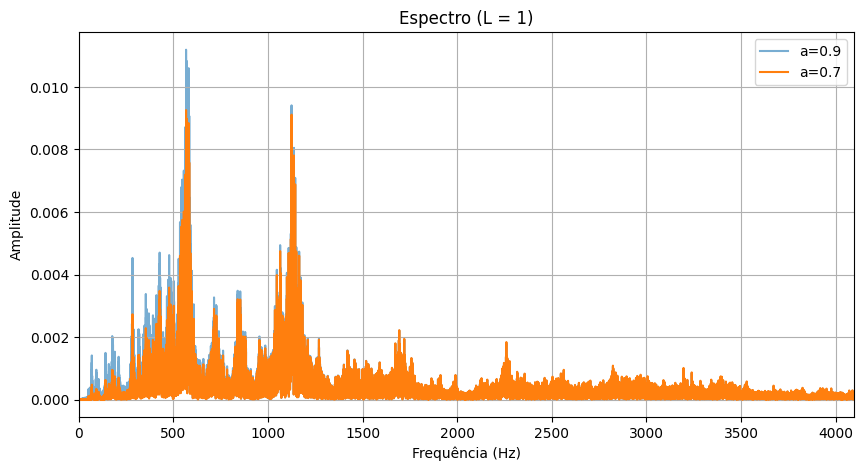

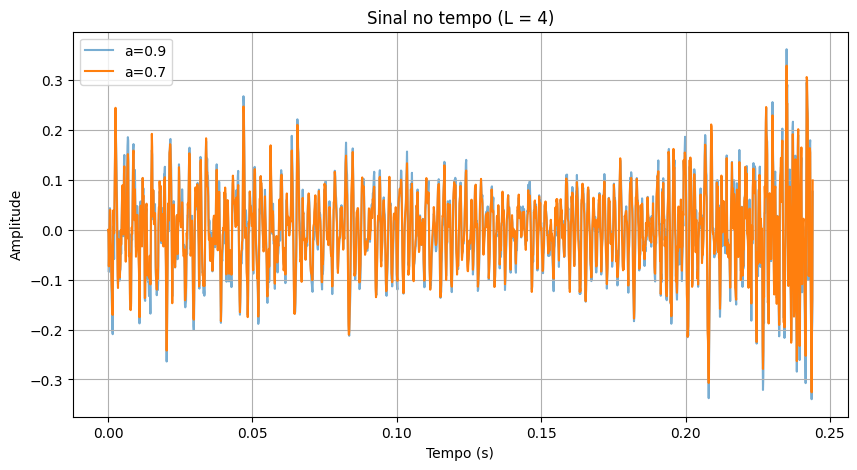

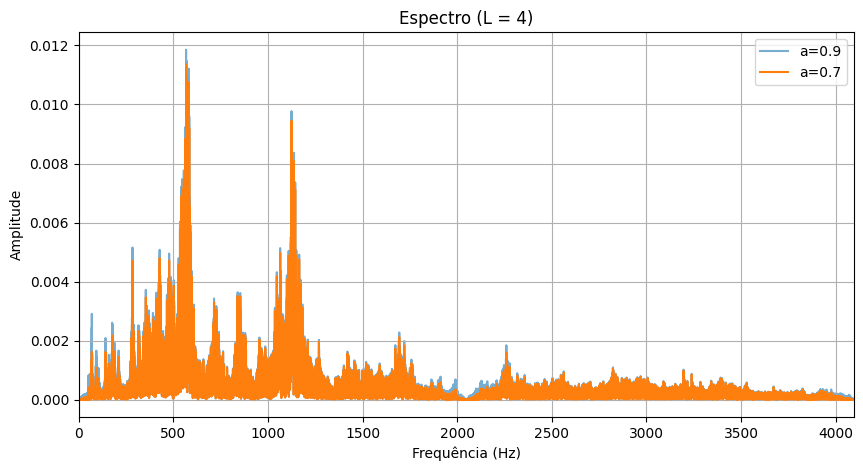

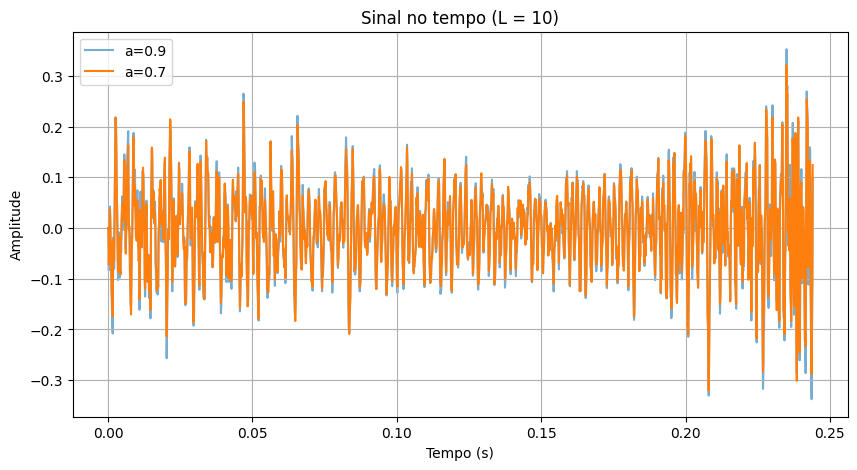

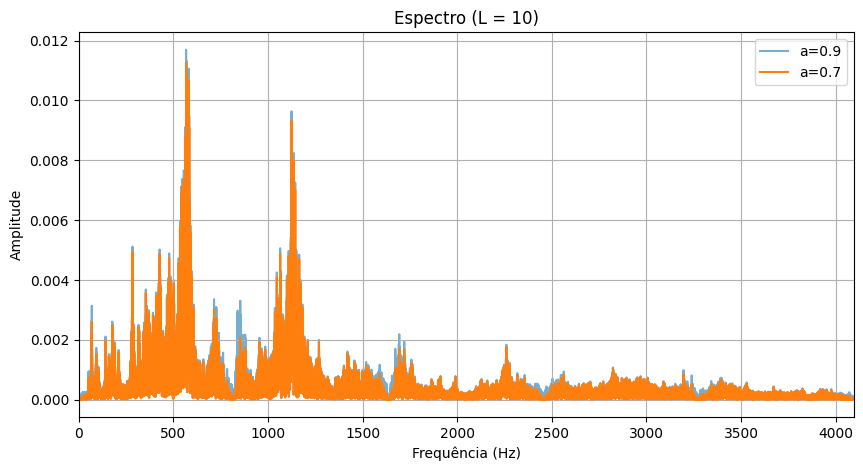

In [ ]:
# Upload do(s) arquivo(s)
uploaded = files.upload()
nomes = list(uploaded.keys())

# Parâmetros
valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

# Ordem de plotagem (fundo → frente)
ordem_a = [0.9, 0.7]

# Controle de profundidade
zordem = {0.9: 1, 0.7: 2}

# Transparência opcional
alpha_vals = {0.9: 0.6, 0.7: 1.0}

for nome in nomes:

    # Leitura do áudio
    fs, x = wav.read(nome)
    x = x.astype(float)
    x = x / np.max(np.abs(x))

    for L in valores_L:

        # Gráfico no TEMPO (a sobrepostos)
        plt.figure(figsize=(10,5))

        for a_val in ordem_a:

            # Sistema
            b = np.zeros(L+1)
            b[0] = 1
            b[-1] = -1

            a = np.zeros(L+1)
            a[0] = 1
            a[-1] = -a_val

            # Aplicação
            y = lfilter(b, a, x)
            y = y / np.max(np.abs(y))

            # Tempo
            t = np.linspace(0, len(y)/fs, len(y))

            plt.plot(
                t[:2000], y[:2000],
                label=f"a={a_val}",
                zorder=zordem[a_val],
                alpha=alpha_vals[a_val]
            )

        plt.title(f"Sinal no tempo (L = {L})")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid()
        plt.show()


        # Gráfico do ESPECTRO (a sobrepostos)
        plt.figure(figsize=(10,5))

        for a_val in ordem_a:

            b = np.zeros(L+1)
            b[0] = 1
            b[-1] = -1

            a = np.zeros(L+1)
            a[0] = 1
            a[-1] = -a_val

            y = lfilter(b, a, x)
            y = y / np.max(np.abs(y))

            f, Y = calculate_spectrum(y, fs)

            plt.plot(
                f, Y,
                label=f"a={a_val}",
                zorder=zordem[a_val],
                alpha=alpha_vals[a_val]
            )

        plt.title(f"Espectro (L = {L})")
        plt.xlabel("Frequência (Hz)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid()
        plt.xlim(0, fs/2)
        plt.show()

Saving handel.wav to handel (7).wav


/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


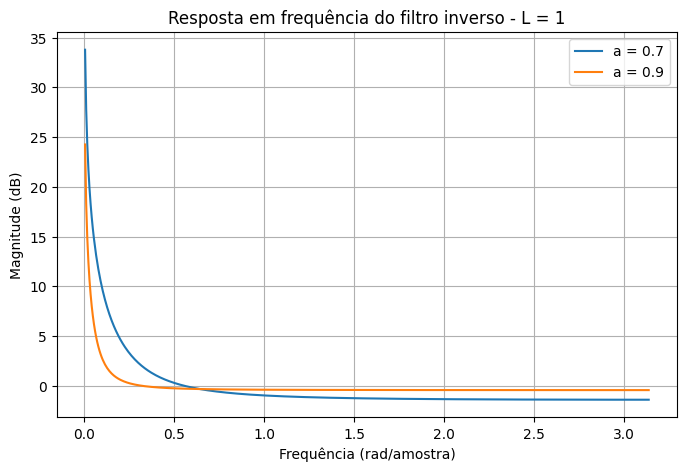

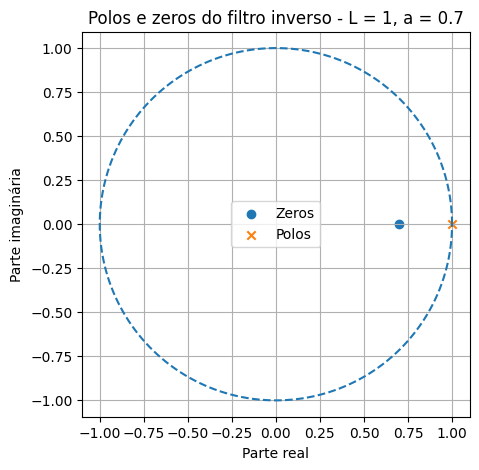

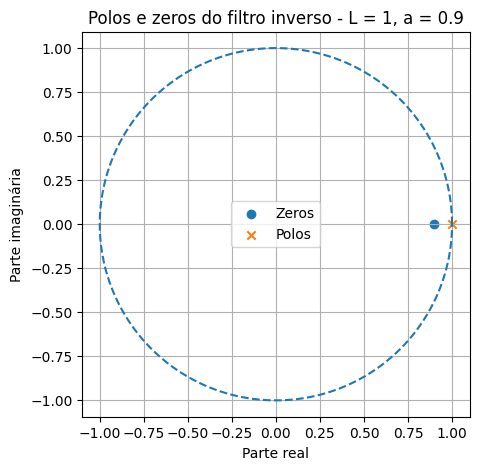

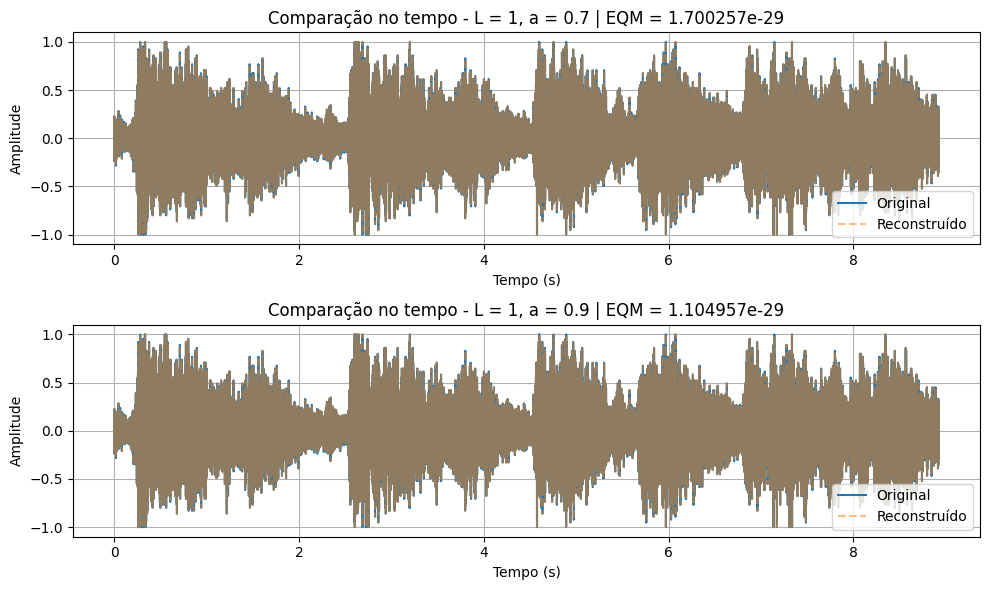

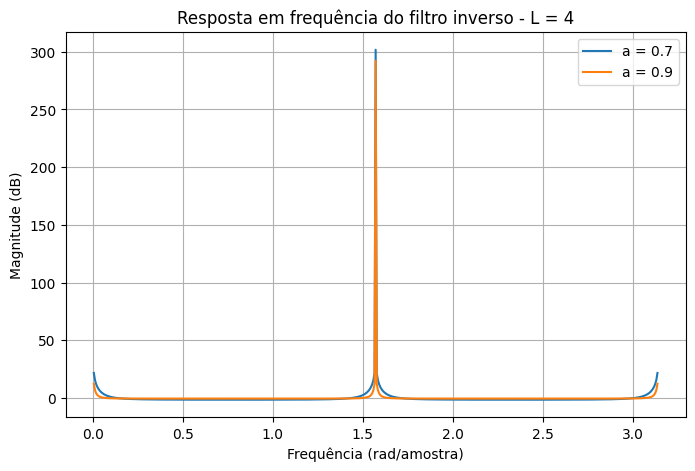

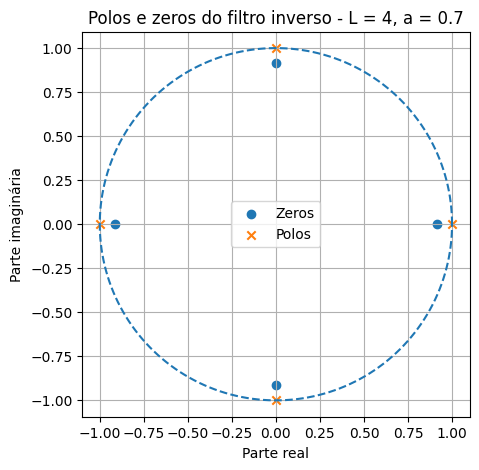

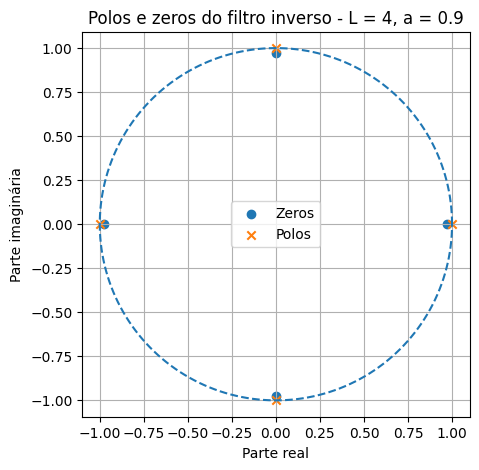

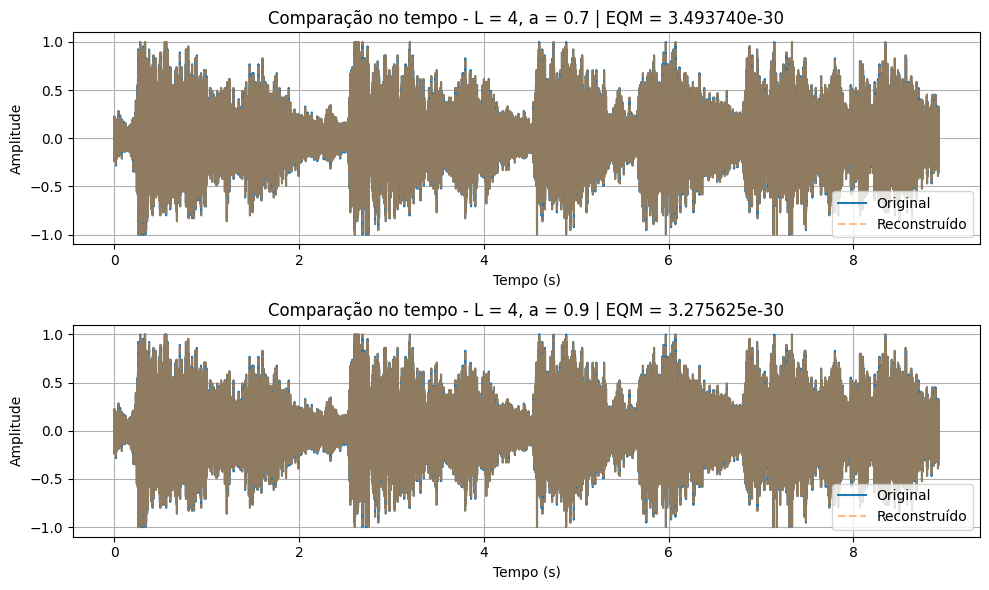

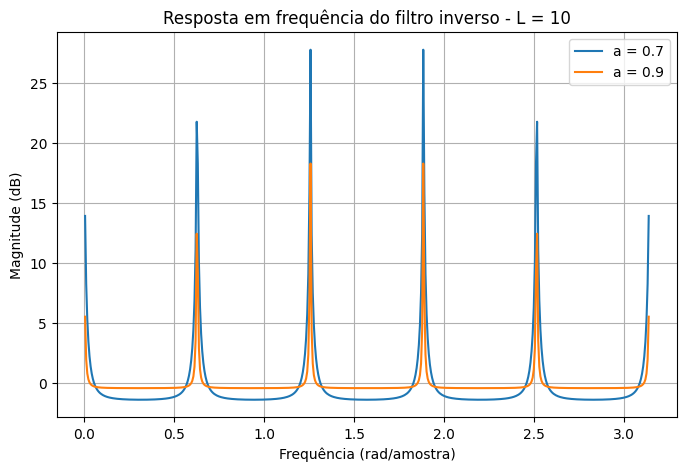

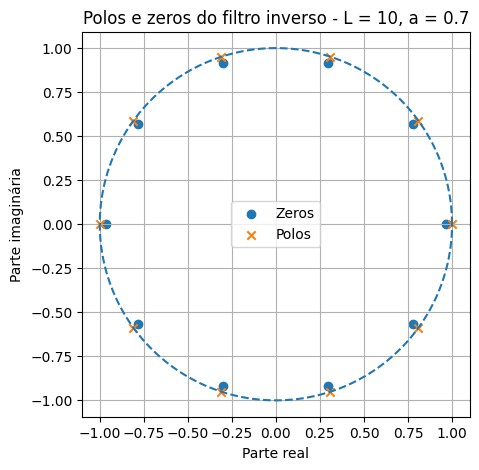

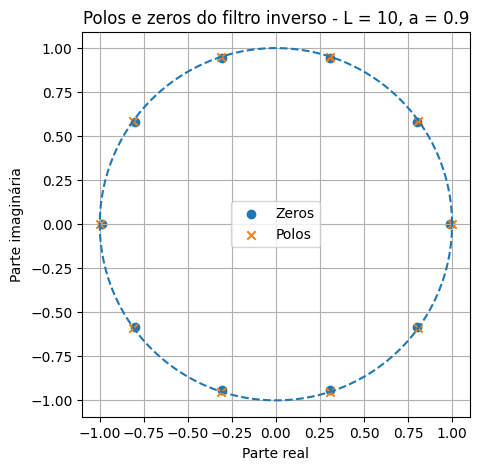

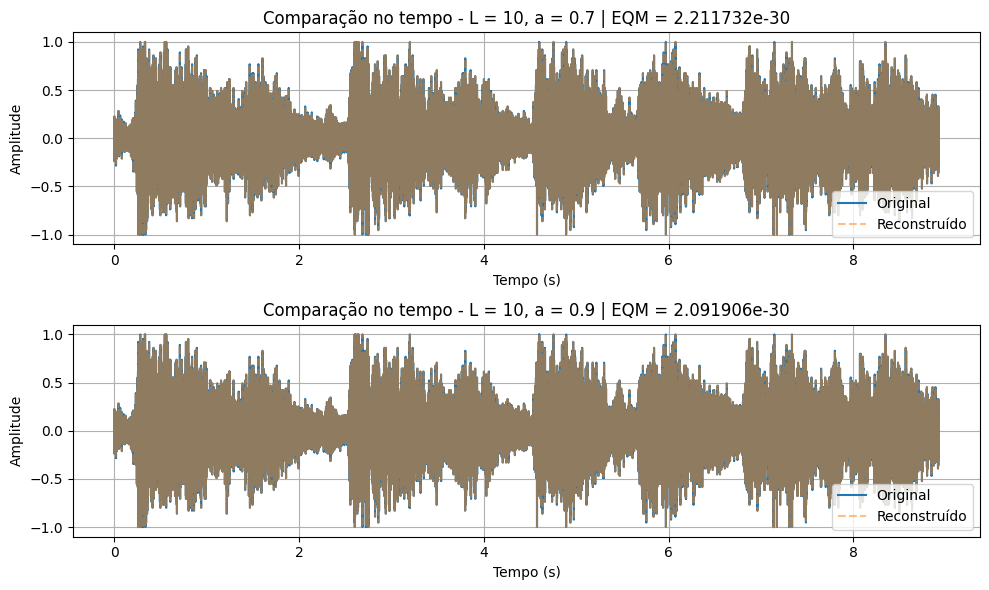

In [9]:
from google.colab import files
import scipy.io.wavfile as wav
from scipy.signal import lfilter, freqz, tf2zpk
import numpy as np
import matplotlib.pyplot as plt

# Upload do arquivo de áudio
uploaded = files.upload()
nomes = list(uploaded.keys())

# Seleção do arquivo de áudio enviado
nome_audio = nomes[0]

# Leitura do sinal
fs, x = wav.read(nome_audio)

# Se o áudio for estéreo, converte para mono fazendo a média dos canais
if len(x.shape) > 1:
    x = np.mean(x, axis=1)

# Conversão para float para permitir processamento numérico adequado
x = x.astype(float)

# Normalização do sinal original
x = x / np.max(np.abs(x))

# Parâmetros do sistema da questão 4
valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

# Vetor de tempo para as comparações
t = np.linspace(0, len(x) / fs, len(x))

for L in valores_L:

    # Resposta em frequência do filtro inverso para o L atual

    plt.figure(figsize=(8, 5))

    for a_val in valores_a:

        # Sistema original
        b = np.zeros(L + 1)
        b[0] = 1
        b[-1] = -1

        a = np.zeros(L + 1)
        a[0] = 1
        a[-1] = -a_val

        # Filtro inverso aproximado: H_inv(z) = 1 / H(z)
        # Isso equivale a trocar numerador e denominador
        b_inv = a
        a_inv = b

        # Resposta em frequência do filtro inverso
        w, H_inv = freqz(b_inv, a_inv)

        # Plot sobreposto para os dois valores de a
        plt.plot(w, 20 * np.log10(np.abs(H_inv) + 1e-12), label=f"a = {a_val}")

    plt.title(f"Resposta em frequência do filtro inverso - L = {L}")
    plt.xlabel("Frequência (rad/amostra)")
    plt.ylabel("Magnitude (dB)")
    plt.grid()
    plt.legend()
    plt.show()

    # Diagramas de polos e zeros para cada valor de a

    for a_val in valores_a:

        # Sistema original
        b = np.zeros(L + 1)
        b[0] = 1
        b[-1] = -1

        a = np.zeros(L + 1)
        a[0] = 1
        a[-1] = -a_val

        # Filtro inverso
        b_inv = a
        a_inv = b

        # Cálculo dos polos e zeros
        zeros, polos, _ = tf2zpk(b_inv, a_inv)

        plt.figure(figsize=(5, 5))

        # Zeros do filtro inverso
        plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label="Zeros")

        # Polos do filtro inverso
        plt.scatter(np.real(polos), np.imag(polos), marker='x', label="Polos")

        # Círculo unitário
        theta = np.linspace(0, 2 * np.pi, 200)
        plt.plot(np.cos(theta), np.sin(theta), linestyle='--')

        plt.title(f"Polos e zeros do filtro inverso - L = {L}, a = {a_val}")
        plt.xlabel("Parte real")
        plt.ylabel("Parte imaginária")
        plt.axis('equal')
        plt.grid()
        plt.legend()
        plt.show()

    # Comparação entre sinal original e sinal reconstruído

    plt.figure(figsize=(10, 6))

    for idx, a_val in enumerate(valores_a, start=1):

        # Sistema original
        b = np.zeros(L + 1)
        b[0] = 1
        b[-1] = -1

        a = np.zeros(L + 1)
        a[0] = 1
        a[-1] = -a_val

        # Aplicação do sistema ao sinal original
        y = lfilter(b, a, x)
        y = y / np.max(np.abs(y))

        # Filtro inverso
        b_inv = a
        a_inv = b

        # Recuperação do sinal
        x_rec = lfilter(b_inv, a_inv, y)
        x_rec = x_rec / np.max(np.abs(x_rec))

        # Erro médio quadrático entre original e recuperado
        mse = np.mean((x - x_rec) ** 2)

        # Subplot para este valor de a
        plt.subplot(2, 1, idx)
        plt.plot(t, x, label="Original")
        plt.plot(t, x_rec, '--', label="Reconstruído", alpha=0.5)
        plt.title(f"Comparação no tempo - L = {L}, a = {a_val} | EQM = {mse:.6e}")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Amplitude")
        plt.grid()
        plt.legend()

    plt.tight_layout()
    plt.show()

Saving handel.wav to handel (9).wav


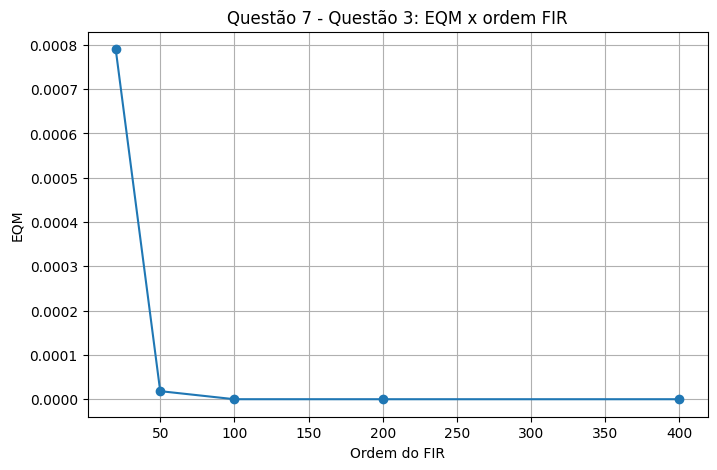

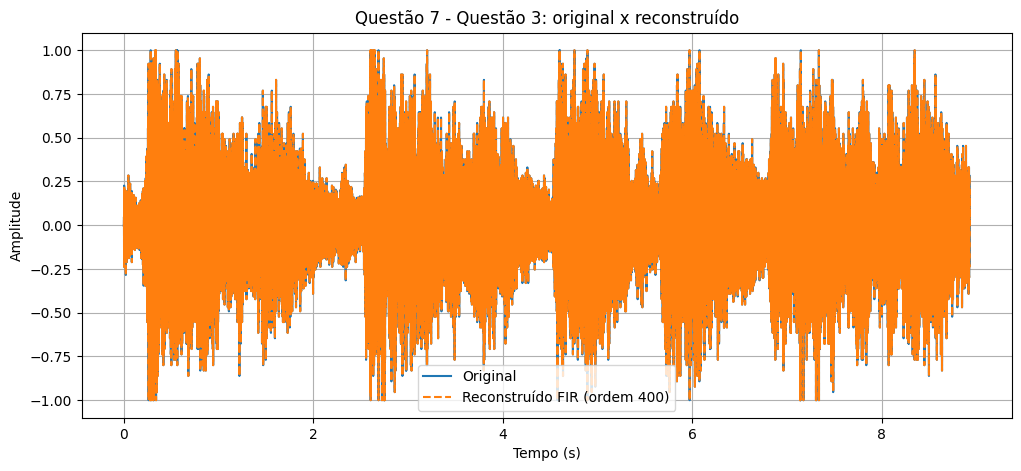

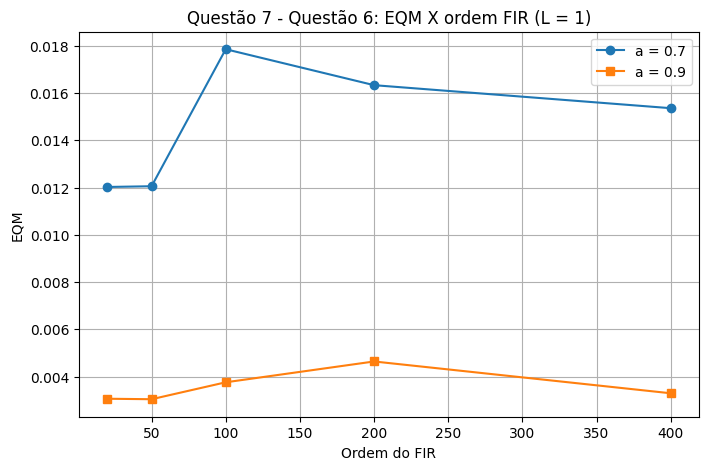

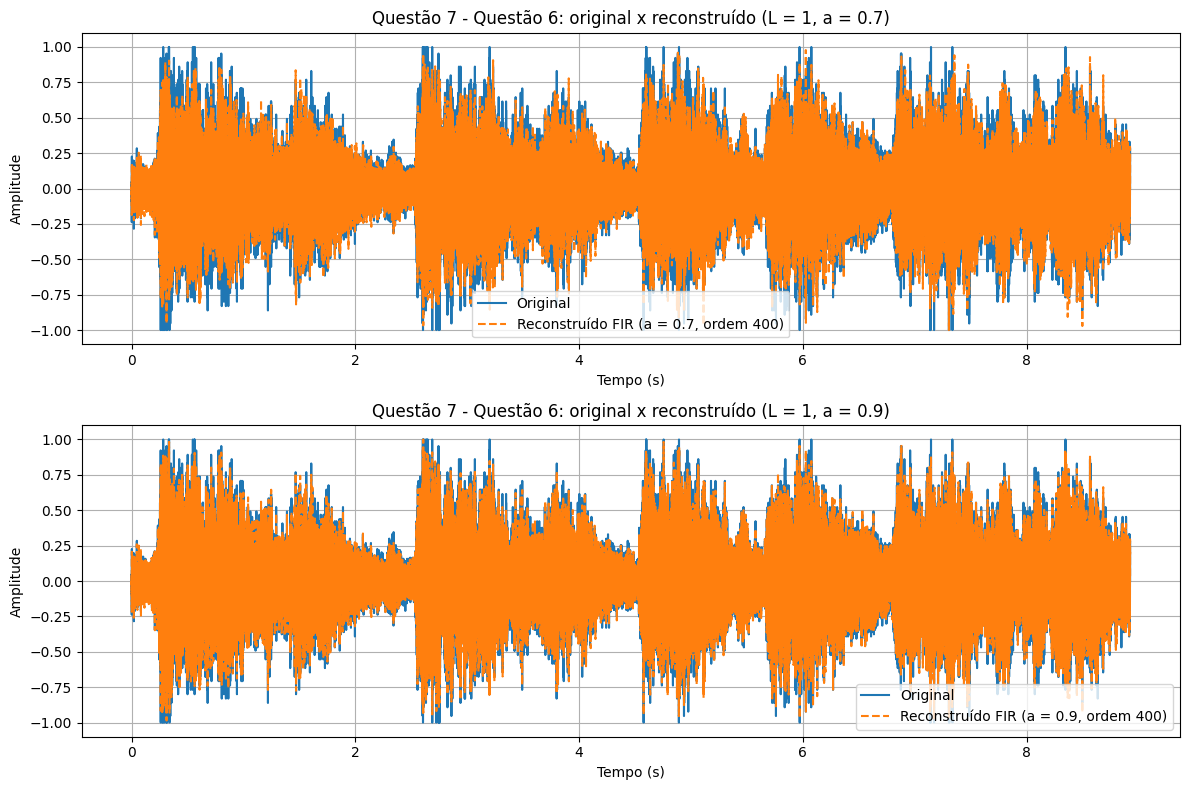

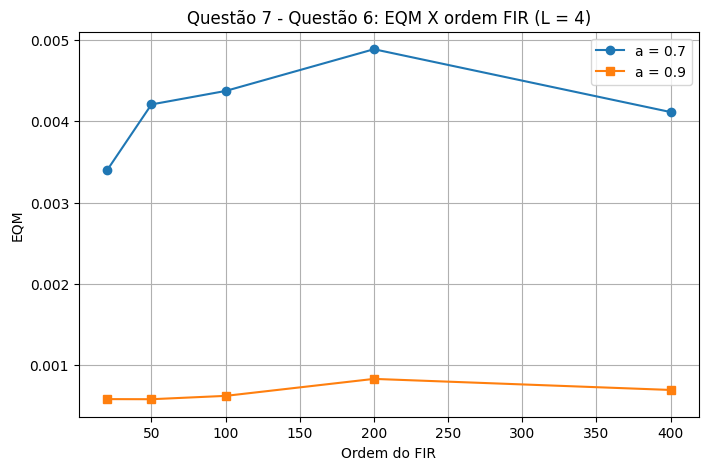

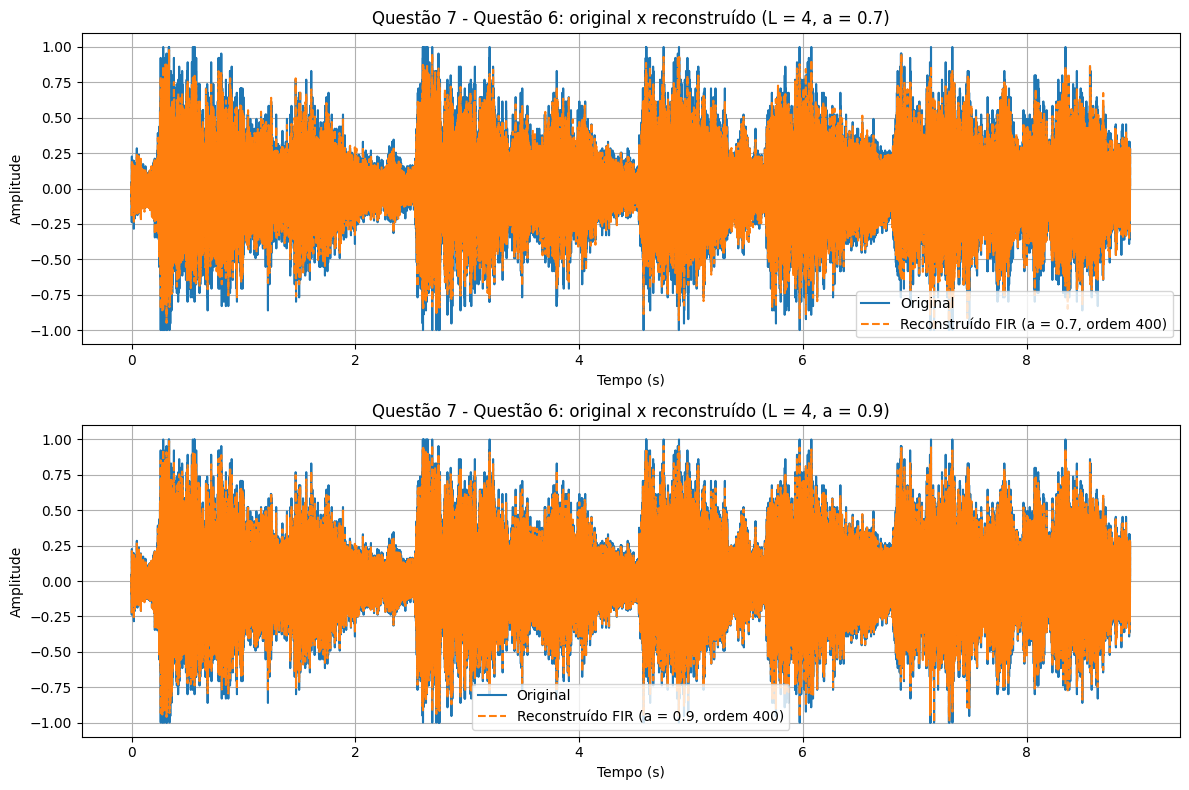

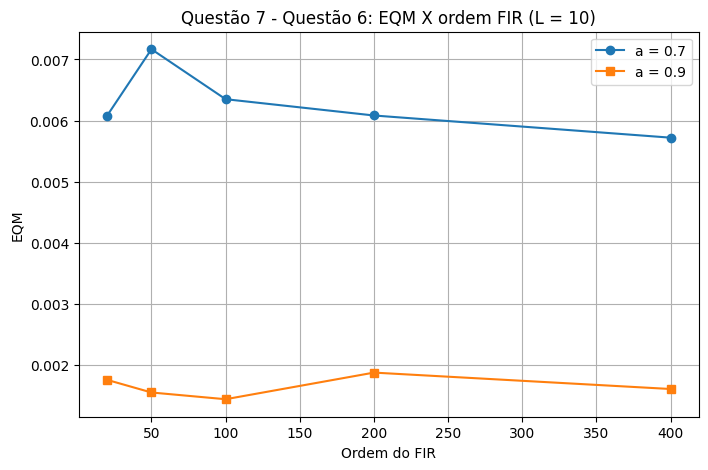

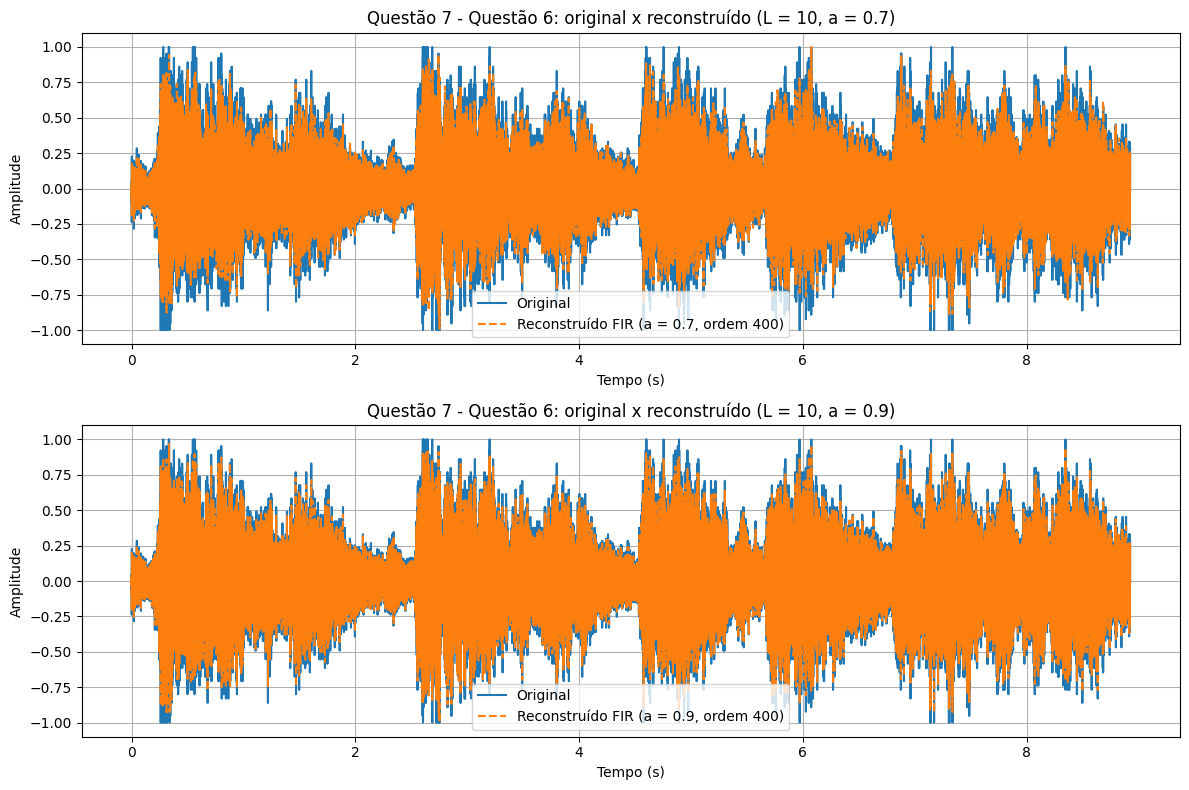

In [11]:
from google.colab import files
import scipy.io.wavfile as wav
from scipy.signal import lfilter
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

# Upload do arquivo de áudio
uploaded = files.upload()
nome_audio = list(uploaded.keys())[0]

# Leitura do arquivo
fs, x = wav.read(nome_audio)

# Se o áudio estiver em estéreo, converte para mono
if len(x.shape) > 1:
    x = np.mean(x, axis=1)

# Converte para float para permitir processamento numérico
x = x.astype(float)

# Normalização do sinal original
x = x / np.max(np.abs(x))

# Vetor de tempo do sinal original
t = np.arange(len(x)) / fs

# Ordens dos filtros FIR aproximados que serão testadas
ordens_fir = [20, 50, 100, 200, 400]

# Resposta ao impulso unitária para obter a resposta dos inversos
impulse_len = 10000
delta = np.zeros(impulse_len)
delta[0] = 1

# APROXIMAÇÃO FIR DO INVERSO DA QUESTÃO 3

# Sistema da questão 3:
b_q3 = np.zeros(13)
b_q3[0] = 1
b_q3[2] = 0.49
b_q3[6] = 0.2401
b_q3[8] = -0.0576
b_q3[10] = -0.0282
b_q3[12] = -0.0138

a_q3 = np.array([1.0])

# Saída do sistema da questão 3
y_q3 = lfilter(b_q3, a_q3, x)
y_q3 = y_q3 / np.max(np.abs(y_q3))

# Filtro inverso ideal do sistema da questão 3
b_inv_q3 = a_q3
a_inv_q3 = b_q3

# Resposta ao impulso do inverso ideal
h_inv_q3 = lfilter(b_inv_q3, a_inv_q3, delta)

# Lista para guardar o erro de cada ordem
mse_q3 = []

# Lista para guardar a reconstrução da maior ordem
x_rec_q3_max = None

# Calcula o erro para cada ordem FIR
for ordem in ordens_fir:
    # Aproximação FIR do inverso por truncamento da resposta ao impulso
    h_fir = h_inv_q3[:ordem]

    # Reconstrução do sinal filtrado
    x_rec = lfilter(h_fir, [1], y_q3)

    # Normalização para visualização e comparação
    x_rec = x_rec / np.max(np.abs(x_rec))

    # Erro médio quadrático entre o original e o reconstruído
    mse = np.mean((x - x_rec) ** 2)
    mse_q3.append(mse)

    # Guarda a reconstrução com a maior ordem
    if ordem == ordens_fir[-1]:
        x_rec_q3_max = x_rec

# Gráfico do erro em função da ordem para a questão 3
plt.figure(figsize=(8, 5))
plt.plot(ordens_fir, mse_q3, marker='o')
plt.title("Questão 7 - Questão 3: EQM x ordem FIR")
plt.xlabel("Ordem do FIR")
plt.ylabel("EQM")
plt.grid()
plt.show()

# Comparação entre sinal original e reconstruído com a maior ordem
plt.figure(figsize=(12, 5))
plt.plot(t, x, label="Original")
plt.plot(t, x_rec_q3_max, '--', label=f"Reconstruído FIR (ordem {ordens_fir[-1]})")
plt.title("Questão 7 - Questão 3: original x reconstruído")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

# QUESTÃO 7 - APROXIMAÇÃO FIR DO INVERSO DA QUESTÃO 6

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

# Para cada valor de L, analisa os dois valores de a
for L in valores_L:

    # Lista para armazenar os erros de cada valor de a
    mse_por_a = {}

    # Lista para armazenar a reconstrução da maior ordem para cada a
    rec_por_a = {}

    # Lista para armazenar as saídas filtradas do sistema original da questão 6
    y_por_a = {}

    # Calcula os resultados para a = 0.7 e a = 0.9
    for a_val in valores_a:
        # Sistema da questão 6:
        # H(z) = (1 - z^-L) / (1 - a z^-L)
        b_q6 = np.zeros(L + 1)
        b_q6[0] = 1
        b_q6[-1] = -1

        a_q6 = np.zeros(L + 1)
        a_q6[0] = 1
        a_q6[-1] = -a_val

        # Saída do sistema original da questão 6
        y_q6 = lfilter(b_q6, a_q6, x)
        y_q6 = y_q6 / np.max(np.abs(y_q6))

        y_por_a[a_val] = y_q6

        # Filtro inverso ideal
        b_inv_q6 = a_q6
        a_inv_q6 = b_q6

        # Resposta ao impulso do inverso ideal
        h_inv_q6 = lfilter(b_inv_q6, a_inv_q6, delta)

        # Lista de erros para as diferentes ordens
        mse_lista = []

        # Reconstrução da maior ordem
        x_rec_max = None

        # Calcula a aproximação FIR para cada ordem
        for ordem in ordens_fir:
            # Truncamento da resposta ao impulso do inverso ideal
            h_fir = h_inv_q6[:ordem]

            # Reconstrução do sinal
            x_rec = lfilter(h_fir, [1], y_q6)

            # Normalização para comparação
            x_rec = x_rec / np.max(np.abs(x_rec))

            # Erro médio quadrático
            mse = np.mean((x - x_rec) ** 2)
            mse_lista.append(mse)

            # Guarda a reconstrução com a maior ordem
            if ordem == ordens_fir[-1]:
                x_rec_max = x_rec

        mse_por_a[a_val] = mse_lista
        rec_por_a[a_val] = x_rec_max

    # Gráfico do erro em função da ordem para L fixo
    plt.figure(figsize=(8, 5))
    plt.plot(ordens_fir, mse_por_a[0.7], marker='o', label='a = 0.7')
    plt.plot(ordens_fir, mse_por_a[0.9], marker='s', label='a = 0.9')
    plt.title(f"Questão 7 - Questão 6: EQM X ordem FIR (L = {L})")
    plt.xlabel("Ordem do FIR")
    plt.ylabel("EQM")
    plt.grid()
    plt.legend()
    plt.show()

    # Comparação entre original e reconstruído para cada valor de a
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(t, x, label="Original")
    plt.plot(t, rec_por_a[0.7], '--', label=f"Reconstruído FIR (a = 0.7, ordem {ordens_fir[-1]})")
    plt.title(f"Questão 7 - Questão 6: original x reconstruído (L = {L}, a = 0.7)")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(t, x, label="Original")
    plt.plot(t, rec_por_a[0.9], '--', label=f"Reconstruído FIR (a = 0.9, ordem {ordens_fir[-1]})")
    plt.title(f"Questão 7 - Questão 6: original x reconstruído (L = {L}, a = 0.9)")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.legend()

    plt.tight_layout()
    plt.show()